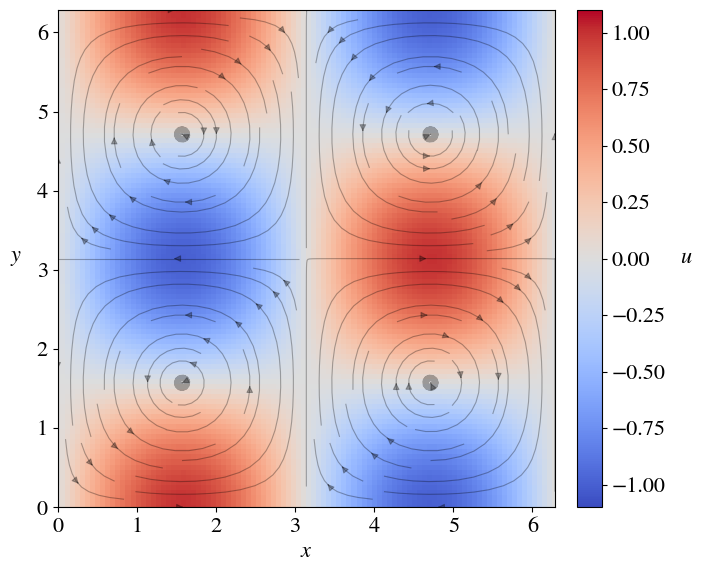

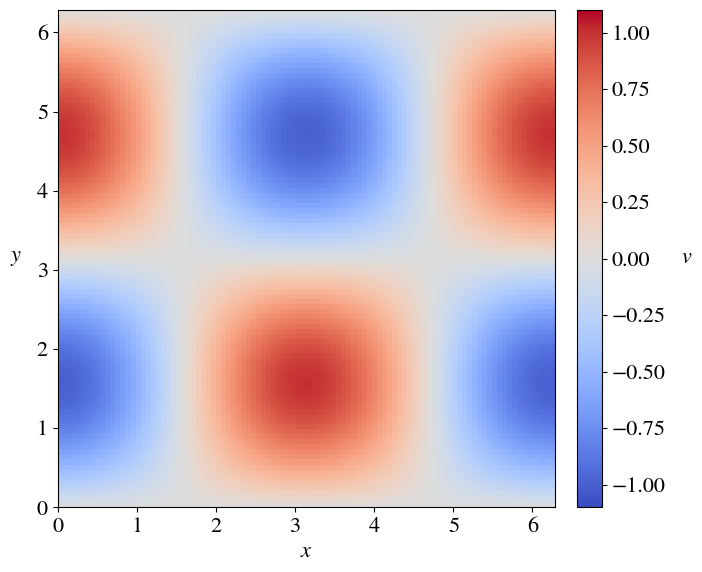

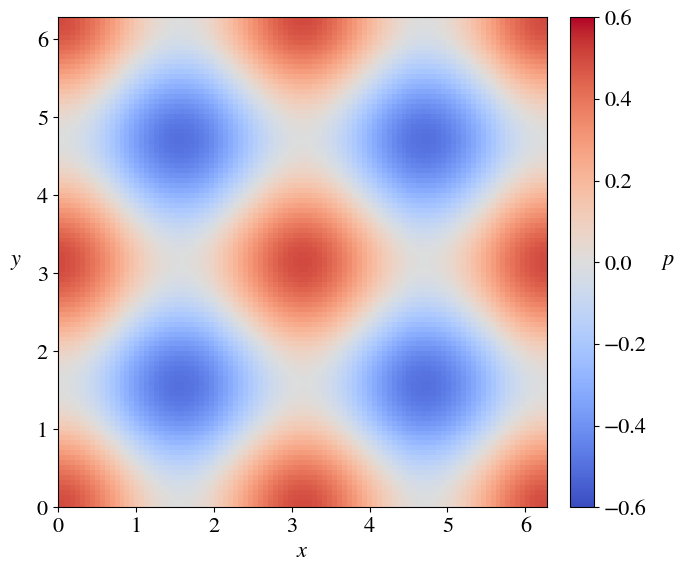

In [2]:
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# Visual setup
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["STIXGeneral"],
    "mathtext.fontset": "stix",
    "font.size": 16
})

# Taylor-Green Parameters
Re = 100.0 
nu_exact = 1/Re  

# Grid
nx, ny = 100, 100
nt = 100
x = np.linspace(0, 2 * np.pi, nx)
y = np.linspace(0, 2 * np.pi, ny)
t = np.linspace(0, 5, nt) 
X_grid, Y_grid = np.meshgrid(x, y)

# Exportation setup (to be use in PINN)
N_points = nx * ny
X_star = np.stack([X_grid.flatten(), Y_grid.flatten()], axis=1)
U_star = np.zeros((N_points, 2, nt))
p_star = np.zeros((N_points, nt))

#Exact velocity and pressure solutions
for i, time_step in enumerate(t):
    decay = np.exp(-2 * nu_exact * time_step) 
    decay_p = np.exp(-4 * nu_exact * time_step) 
    
    U_star[:, 0, i] = (np.sin(X_grid) * np.cos(Y_grid) * decay).flatten()
    U_star[:, 1, i] = (-np.cos(X_grid) * np.sin(Y_grid) * decay).flatten()
    p_star[:, i]    = (0.25 * (np.cos(2 * X_grid) + np.cos(2 * Y_grid)) * decay_p).flatten()


#Export file
output_file = 'taylor_green_data.mat'
sio.savemat(output_file, {
    'X_star': X_star, 
    't': t.reshape(-1, 1),
    'U_star': U_star, 
    'p_star': p_star
})


# Visualization t=0
u_t0 = U_star[:, 0, 0].reshape(ny, nx)
v_t0 = U_star[:, 1, 0].reshape(ny, nx)
p_t0 = p_star[:, 0].reshape(ny, nx)

# Global aesthetic parameters
cmap_opt = 'coolwarm'
label_font = 16
rot_val = 0
pad_val = 15

# Normalization limits for colors
v_lim_vel = 1.1 # Rango [-1.1, 1.1] para u, v
v_lim_pres = 0.6 # Rango [-0.6, 0.6] para p

# Visualization: Velocity u
fig_u, ax_u = plt.subplots(figsize=(7, 6))

# Colormap
c0 = ax_u.pcolormesh(X_grid, Y_grid, u_t0, cmap=cmap_opt, shading='auto', 
                     vmin=-v_lim_vel, vmax=v_lim_vel)

cbar_u = fig_u.colorbar(c0, ax=ax_u, fraction=0.046, pad=0.04)
cbar_u.set_label(r'$u$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')

# Streamlines
ax_u.streamplot(x, y, u_t0, v_t0, color=(0, 0, 0, 0.3), 
                density=1.1, linewidth=0.8, arrowsize=1.0)

ax_u.set_xlabel(r'$x$', fontsize=label_font)
ax_u.set_ylabel(r'$y$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_u.set_xlim(0, 2*np.pi)
ax_u.set_ylim(0, 2*np.pi)
ax_u.set_aspect('equal')

plt.tight_layout()
fig_u.savefig('Images/TaylorGreen_U.png', dpi=300, bbox_inches='tight')

# Visualization: Velocity v
fig_v, ax_v = plt.subplots(figsize=(7, 6))
c1 = ax_v.pcolormesh(X_grid, Y_grid, v_t0, cmap=cmap_opt, shading='auto', 
                     vmin=-v_lim_vel, vmax=v_lim_vel)

cbar_v = fig_v.colorbar(c1, ax=ax_v, fraction=0.046, pad=0.04)
cbar_v.set_label(r'$v$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')

ax_v.set_xlabel(r'$x$', fontsize=label_font)
ax_v.set_ylabel(r'$y$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_v.set_xlim(0, 2*np.pi)
ax_v.set_ylim(0, 2*np.pi)
ax_v.set_aspect('equal')

plt.tight_layout()
fig_v.savefig('Images/TaylorGreen_V.png', dpi=300, bbox_inches='tight')

# Visualization: Pressure
fig_p, ax_p = plt.subplots(figsize=(7, 6))
c2 = ax_p.pcolormesh(X_grid, Y_grid, p_t0, cmap=cmap_opt, shading='auto', 
                     vmin=-v_lim_pres, vmax=v_lim_pres)

cbar_p = fig_p.colorbar(c2, ax=ax_p, fraction=0.046, pad=0.04)
cbar_p.set_label(r'$p$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')

ax_p.set_xlabel(r'$x$', fontsize=label_font)
ax_p.set_ylabel(r'$y$', rotation=rot_val, labelpad=pad_val, fontsize=label_font, va='center')
ax_p.set_xlim(0, 2*np.pi)
ax_p.set_ylim(0, 2*np.pi)
ax_p.set_aspect('equal')

plt.tight_layout()
fig_p.savefig('Images/TaylorGreen_P.png', dpi=300, bbox_inches='tight')

plt.show()